# CS590 - Intensive Python for Data Science
## Capstone: Multi-Class Mental Health Condition Detection in Reddit Posts

**Author:** Asha Shah &nbsp;|&nbsp; **Spring 2026**

---

### Dataset Download Instructions

This notebook requires the **Reddit Mental Health Dataset** from Kaggle.

**Steps:**
1. Create a free account at [kaggle.com](https://www.kaggle.com)
2. Install the Kaggle API: `pip install kaggle`
3. Place your `kaggle.json` API token in `~/.kaggle/kaggle.json`
4. Run the cell below to download and unzip the dataset

```bash
kaggle datasets download -d neelghoshal/reddit-mental-health-data
unzip reddit-mental-health-data.zip
```

The CSV file should be named `data_to_be_cleansed.csv` and placed in the **same directory as this notebook**.

---

### Pipeline Overview

| Step | Section | Description |
|------|---------|-------------|
| 0 | Setup | Install dependencies |
| 1 | Data Loading & Cleaning | Load CSV, drop nulls, clean text |
| 2 | EDA | Class distribution, post length, sentiment, word clouds |
| 3 | TF-IDF + Logistic Regression | Baseline model with 5-fold CV |
| 4 | Random Forest | Ensemble model + feature importance |
| 5 | DistilBERT Fine-Tuning | Transformer model (CS590 extension) |
| 6 | SHAP Explainability | Model interpretation (CS590 extension) |


## Section 0: Setup
Install all required packages. Run once; safe to re-run.

In [1]:
pip install pandas numpy matplotlib seaborn wordcloud scikit-learn vaderSentiment shap transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.8 MB/s eta 0:00:00


## Section 1: Imports, Constants, and Global Helpers


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd               # DataFrame operations
import numpy as np                # Numerical array operations
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Statistical visualisation (built on matplotlib)
from wordcloud import WordCloud   # Word cloud generation

import re                         # Regular expressions for text cleaning
import warnings
warnings.filterwarnings("ignore") # Suppress deprecation warnings for clean output

# scikit-learn: vectorisation, models, evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)

# VADER: rule-based sentiment analyser well-suited to social media text
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# SHAP: model-agnostic explainability (SHapley Additive exPlanations)
import shap

# PyTorch + Hugging Face: required for DistilBERT fine-tuning (Section 5)
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# =============================================================================
# GLOBAL CONSTANTS
# =============================================================================

CSV_FILE     = "data_to_be_cleansed.csv"   # Path to downloaded dataset CSV

# Mapping from integer label → human-readable condition name
LABEL_MAP    = {0: "Stress", 1: "Depression",
                2: "Bipolar", 3: "Personality Disorder", 4: "Anxiety"}
NUM_LABELS   = 5          # Total number of target classes

RANDOM_STATE = 42         # Seed for all random operations (ensures reproducibility)
N_SPLITS     = 5          # Number of folds for stratified k-fold cross-validation

# DistilBERT-specific constants
MAX_LEN      = 256        # Maximum token length per post (truncate/pad to this)
BERT_EPOCHS  = 3          # Training epochs for fine-tuning
BERT_BATCH   = 16         # Mini-batch size (reduce to 8 if running on <8 GB RAM)

# =============================================================================
# SHARED HELPER: CONFUSION MATRIX PLOT
# =============================================================================

def _plot_confusion(y_true, y_pred, title: str, filename: str):
    """
    Plot and save a labelled confusion matrix.

    Parameters
    ----------
    y_true   : array-like - ground-truth class labels
    y_pred   : array-like - predicted class labels
    title    : str        - plot title
    filename : str        - filename to save the PNG
    """
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(LABEL_MAP.values())
    )
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)   # Save for inclusion in the report
    plt.show()


## Section 2: Data Loading & Cleaning

**Dataset:** Reddit Mental Health Dataset containing 5,957 posts collected from five subreddits on mental health topics.

**Cleaning steps applied:**
1. Discard data entries rows with missing `text` or `target` (dropping 350 records, resulting in 5,607 data records)
2. Concatenate `title` + `text` into a single `combined` field (missing titles filled with `""`)
3. Data preprocessing steps: lower case transformation, removal of links (URLs), removal of Markdown-style links, elimination of non-alphabetical symbols (excepting apostrophes), and reduction of multiple spaces.

**Why combine title + text?**
Title often represents the most coherent representation of what a blog post is about (e.g., “I’ve been diagnosed with BPD”). Thus, their use will strengthen our signal.

**Why sublinear TF?**
Sublinear TF will be useful in the next step with the TF-IDF because it reduces the effect of very high frequency words from dominating the feature space.

In [5]:
def load_and_clean(filepath: str) -> pd.DataFrame:
    """
    Load the Reddit Mental Health CSV and return a cleaned DataFrame.

    Steps:
      - Load CSV data and check its shape.
      - Drop rows missing 'text' or 'target' (required fields)
      - Merge title + text into 'combined'
      - Clean the text with regex and save result in 'clean_text'.
      - Convert 'target' into integers and create 'label_name'.

    Parameters
    ----------
    filepath : str - path to the raw CSV file

    Returns
    -------
    pd.DataFrame with columns: text, title, target, combined, clean_text, label_name
    """
    df = pd.read_csv(filepath)
    print(f"Raw dataset: {df.shape[0]} rows × {df.shape[1]} columns")
    print(df.head())

    # --- Drop rows with missing required fields ---
    before = len(df)
    df = df.dropna(subset=["text", "target"])
    print(f"\nDropped {before - len(df)} rows with missing text or target.")

    # --- Merge title into text ---
    # Fill missing titles with empty string so concatenation never produces NaN
    df["title"]    = df["title"].fillna("")
    df["combined"] = df["title"] + " " + df["text"]

    # --- Text cleaning pipeline ---
    def clean(txt):
        txt = str(txt).lower()                          # 1. Lowercase
        txt = re.sub(r"http\S+|www\.\S+", "", txt)   # 2. Remove URLs
        txt = re.sub(r"\[.*?\]|\(.*?\)", "", txt)     # 3. Remove Markdown links
        txt = re.sub(r"[^a-z\s']", " ", txt)           # 4. Keep only letters & apostrophes
        txt = re.sub(r"\s+", " ", txt).strip()          # 5. Collapse whitespace
        return txt

    df["clean_text"] = df["combined"].apply(clean)

    # --- Encode target ---
    df["target"]     = df["target"].astype(int)
    df["label_name"] = df["target"].map(LABEL_MAP)

    print(f"\nAfter cleaning: {df.shape[0]} rows retained")
    print("\nClass distribution (should be near-balanced):")
    print(df["label_name"].value_counts())
    return df


# Run data loading: all downstream cells depend on this DataFrame
df = load_and_clean(CSV_FILE)


Raw dataset: 5957 rows × 4 columns
   Unnamed: 0                                               text  \
0           0  Welcome to /r/depression's check-in post - a p...   
1           1  We understand that most people who reply immed...   
2           2  Anyone else just miss physical touch? I crave ...   
3           3  I’m just so ashamed. Everyone and everything f...   
4           4  I really need a friend. I don't even have a si...   

                                               title  target  
0  Regular check-in post, with information about ...       1  
1  Our most-broken and least-understood rules is ...       1  
2  I haven’t been touched, or even hugged, in so ...       1  
3                    Being Depressed is Embarrassing       1  
4  I'm desperate for a friend and to feel loved b...       1  

Dropped 350 rows with missing text or target.

After cleaning: 5607 rows retained

Class distribution (should be near-balanced):
label_name
Depression              1202
Anxiety 

## Section 3: Exploratory Data Analysis (EDA)

Four visualisations are produced:

| Figure | What it shows | Why it matters |
|--------|--------------|----------------|
| 3a. Class distribution | Number of posts per class | Reflects class balance and serves as evidence for using macro F1 |
| 3b. Post length | Word count per class (box plot) | Indicates that differences in length serve as a partial discriminant signal |
| 3c. VADER sentiment | Compound sentiment by class | Measures differences in emotions between classes |
| 3d. Word clouds | Top 80 terms per class | Allows for visualization of vocabulary used in each class. |

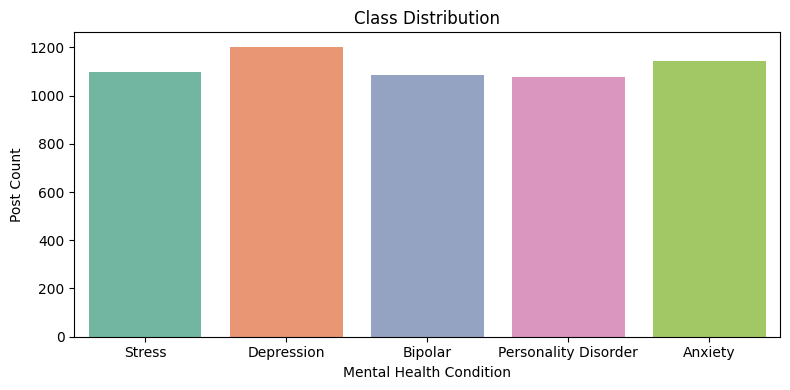

Post length (words) by class:
                       count   mean    std  min   25%    50%    75%     max
label_name                                                                 
Anxiety               1144.0  160.3  155.9  5.0  65.0  112.5  196.0  1483.0
Bipolar               1085.0  161.1  134.0  4.0  75.0  122.0  202.0  1566.0
Depression            1202.0  172.3  156.9  6.0  62.0  129.0  228.5  1602.0
Personality Disorder  1077.0  177.4  219.6  3.0  65.0  135.0  234.0  5382.0
Stress                1099.0  146.0  146.2  2.0  52.0  104.0  189.5  1592.0


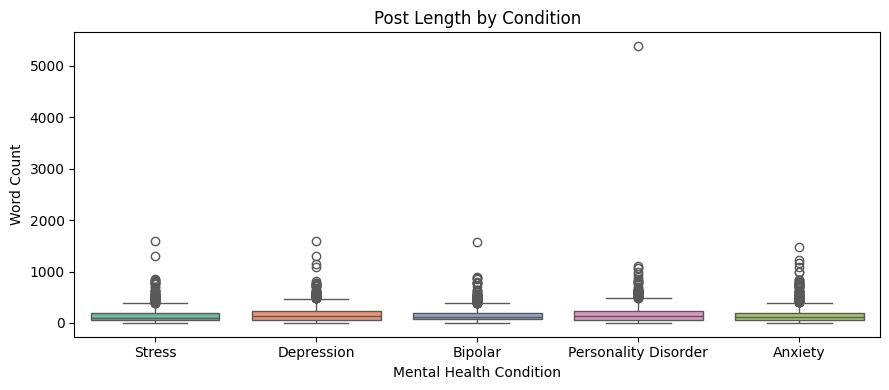

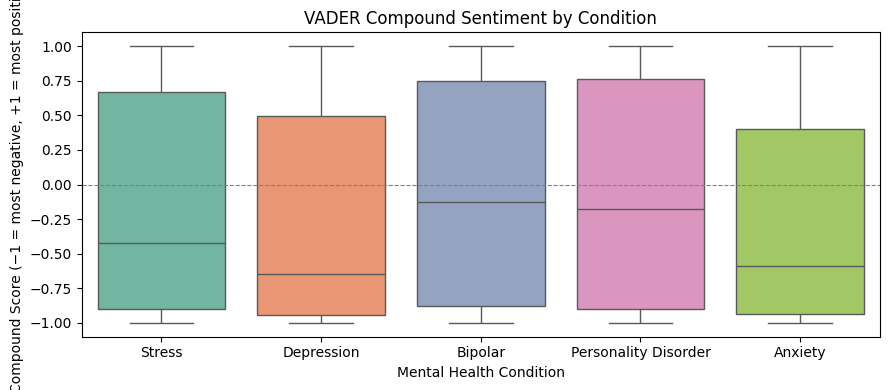

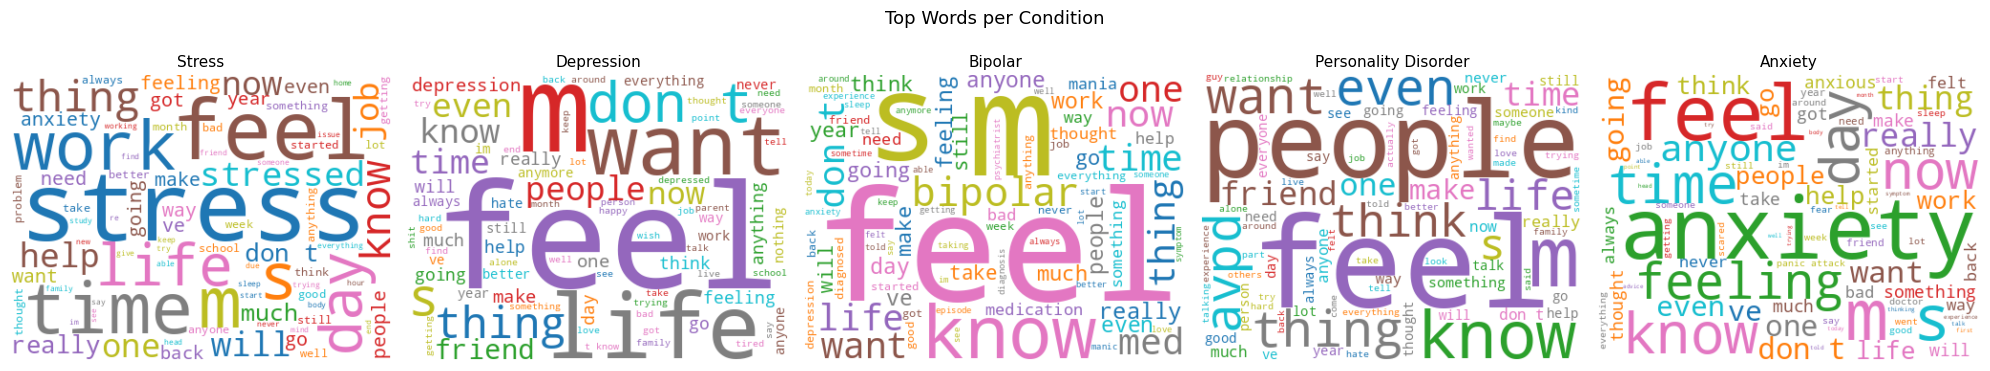

In [6]:
def run_eda(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform exploratory data analysis and save all figures.

    Produces four labelled visualisations:
      (a) Class distribution bar chart
      (b) Post length box plots by condition
      (c) VADER compound sentiment box plots
      (d) Word clouds (one per class)

    Parameters
    ----------
    df : pd.DataFrame - cleaned DataFrame from load_and_clean()

    Returns
    -------
    pd.DataFrame - input df enriched with 'post_len' and 'sentiment' columns
    """
    # Consistent class ordering for all plots
    order = [LABEL_MAP[i] for i in range(NUM_LABELS)]

    # ── 3a. Class Distribution ────────────────────────────────────────────────
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x="label_name", order=order, palette="Set2")
    plt.title("Class Distribution")
    plt.xlabel("Mental Health Condition")
    plt.ylabel("Post Count")
    plt.tight_layout()
    plt.savefig("eda_class_distribution.png", dpi=150)
    plt.show()

    # ── 3b. Post Length ───────────────────────────────────────────────────────
    df["post_len"] = df["clean_text"].apply(lambda x: len(x.split()))
    print("Post length (words) by class:")
    print(df.groupby("label_name")["post_len"].describe().round(1))

    plt.figure(figsize=(9, 4))
    sns.boxplot(data=df, x="label_name", y="post_len", order=order, palette="Set2")
    plt.title("Post Length by Condition")
    plt.xlabel("Mental Health Condition")
    plt.ylabel("Word Count")
    plt.tight_layout()
    plt.savefig("eda_post_length.png", dpi=150)
    plt.show()

    # ── 3c. VADER Sentiment ───────────────────────────────────────────────────
    analyzer      = SentimentIntensityAnalyzer()
    df["sentiment"] = df["clean_text"].apply(
        lambda x: analyzer.polarity_scores(x)["compound"]
    )

    plt.figure(figsize=(9, 4))
    sns.boxplot(data=df, x="label_name", y="sentiment", order=order, palette="Set2")
    plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)  # Neutral baseline
    plt.title("VADER Compound Sentiment by Condition")
    plt.xlabel("Mental Health Condition")
    plt.ylabel("Compound Score (−1 = most negative, +1 = most positive)")
    plt.tight_layout()
    plt.savefig("eda_sentiment.png", dpi=150)
    plt.show()

    # ── 3d. Word Clouds ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, NUM_LABELS, figsize=(20, 4))
    for i, ax in enumerate(axes):
        subset = " ".join(df[df["target"] == i]["clean_text"])   # All text for class i
        wc = WordCloud(
            width=400, height=300,
            background_color="white",
            max_words=80,
            colormap="tab10"
        ).generate(subset)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(LABEL_MAP[i], fontsize=11)
        ax.axis("off")   # Hide axes for cleaner display
    plt.suptitle("Top Words per Condition", fontsize=13)
    plt.tight_layout()
    plt.savefig("eda_wordclouds.png", dpi=150)
    plt.show()

    return df   # Return df with new post_len and sentiment columns

df = run_eda(df)


## Section 4: Baseline Model: TF-IDF + Logistic Regression

**Why this model first?**  
Logistic Regression with TF-IDF features is the traditional NLP baseline solution, which is efficient, explainable, and performs well. If this method achieves adequate results, then we set an extremely high bar for other advanced models to beat.

**Evaluation:** Five-fold stratified cross-validation produces out-of-fold predictions on all 5,607 posts, resulting in an unbiased estimate that leverages the whole dataset. Macro F1 is the main evaluation measure, indicating the same weight is given to all classes.

**Key hyperparameters:**
- `max_features=30,000`, `ngram_range=(1,2)` : unigrams + bigrams; bigrams capture phrases like "panic attack"
- `sublinear_tf=True` : log-scales term frequencies; reduces dominance of very common words
- `class_weight='balanced'` : compensates for any residual class imbalance
- `C=1.0` : default regularisation strength (L2 penalty)


BASELINE: TF-IDF + Logistic Regression (5-fold CV)
                      precision    recall  f1-score   support

              Stress       0.90      0.83      0.86      1099
          Depression       0.72      0.79      0.75      1202
             Bipolar       0.88      0.83      0.85      1085
Personality Disorder       0.77      0.82      0.79      1077
             Anxiety       0.82      0.78      0.80      1144

            accuracy                           0.81      5607
           macro avg       0.82      0.81      0.81      5607
        weighted avg       0.81      0.81      0.81      5607

Macro F1: 0.8125


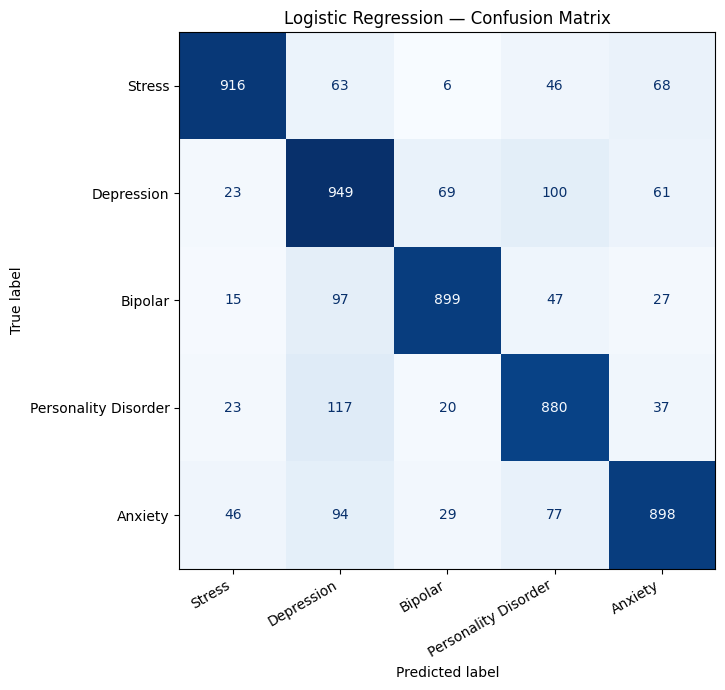

In [7]:
def tfidf_logreg(df: pd.DataFrame):
    """
    Train and evaluate a TF-IDF + Logistic Regression pipeline via 5-fold CV.

    Also fits the full pipeline on all data so it can be used for SHAP
    explainability in Section 6.

    Parameters
    ----------
    df : pd.DataFrame - cleaned DataFrame with 'clean_text' and 'target'

    Returns
    -------
    pipeline : fitted sklearn Pipeline (TfidfVectorizer → LogisticRegression)
    """
    print("\n" + "="*60)
    print("BASELINE: TF-IDF + Logistic Regression (5-fold CV)")
    print("="*60)

    X = df["clean_text"]   # Feature: cleaned post text
    y = df["target"]       # Target: integer class label (0–4)

    # This prevents data leakage: the vectoriser is fit only on training folds.
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=30_000,    # Cap vocabulary to top 30k terms by TF-IDF score
            ngram_range=(1, 2),     # Include bigrams (e.g., "panic attack", "feeling numb")
            sublinear_tf=True,      # Apply log(1 + TF) - reduces impact of very frequent terms
            min_df=2                # Ignore terms appearing in fewer than 2 documents
        )),
        ("clf", LogisticRegression(
            max_iter=1000,          # Increase from default 100 to ensure convergence
            C=1.0,                  # Inverse regularisation strength (higher = less regularisation)
            class_weight="balanced",# Weight classes inversely proportional to frequency
            random_state=RANDOM_STATE
        ))
    ])

    # Stratified k-fold ensures each fold has the same class proportions as the full dataset
    skf    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    y_pred = cross_val_predict(pipeline, X, y, cv=skf)   # Out-of-fold predictions

    # Per-class precision, recall, F1-score, and support
    print(classification_report(y, y_pred, target_names=list(LABEL_MAP.values())))

    macro_f1 = f1_score(y, y_pred, average="macro")
    print(f"Macro F1: {macro_f1:.4f}")

    # Visualise where the model makes mistakes
    _plot_confusion(y, y_pred, "Logistic Regression - Confusion Matrix", "cm_logreg.png")

    # Re-fit on the full dataset, needed for SHAP explainability in Section 6
    pipeline.fit(X, y)
    return pipeline


lr_pipeline = tfidf_logreg(df)


## Section 5: Random Forest with Feature Importance

**Why Random Forest?**  
As an ensemble learning approach using decision trees, Random Forest has its own particular inductive bias compared to the logistic regression and has a feature importance criterion based on Gini score that tells which vocabulary terms are used the most by the model.

**Key differences from the baseline:**
- Vocabulary consists of only 10,000 features (instead of 30,000); the Random Forest method is slower and consumes more resources compared to logistic regression for working with sparse matrixes.
- Feature importance is obtained based on fully trained model on the whole dataset and is visualized for the 20 most important features.
- Cross validation remains the same, i.e. 5-fold.


Random Forest + Feature Importance (5-fold CV)
                      precision    recall  f1-score   support

              Stress       0.88      0.85      0.86      1099
          Depression       0.70      0.84      0.76      1202
             Bipolar       0.92      0.85      0.88      1085
Personality Disorder       0.82      0.76      0.79      1077
             Anxiety       0.83      0.80      0.81      1144

            accuracy                           0.82      5607
           macro avg       0.83      0.82      0.82      5607
        weighted avg       0.83      0.82      0.82      5607

Macro F1: 0.8234


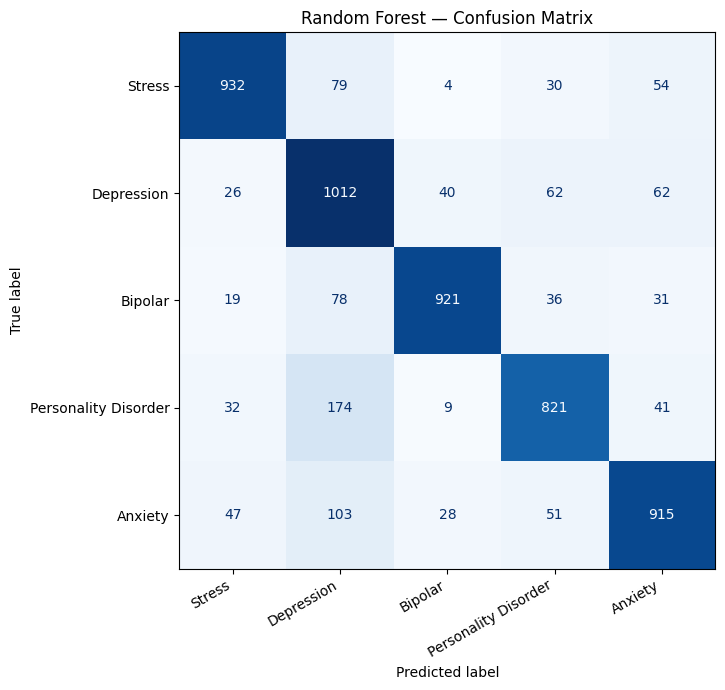

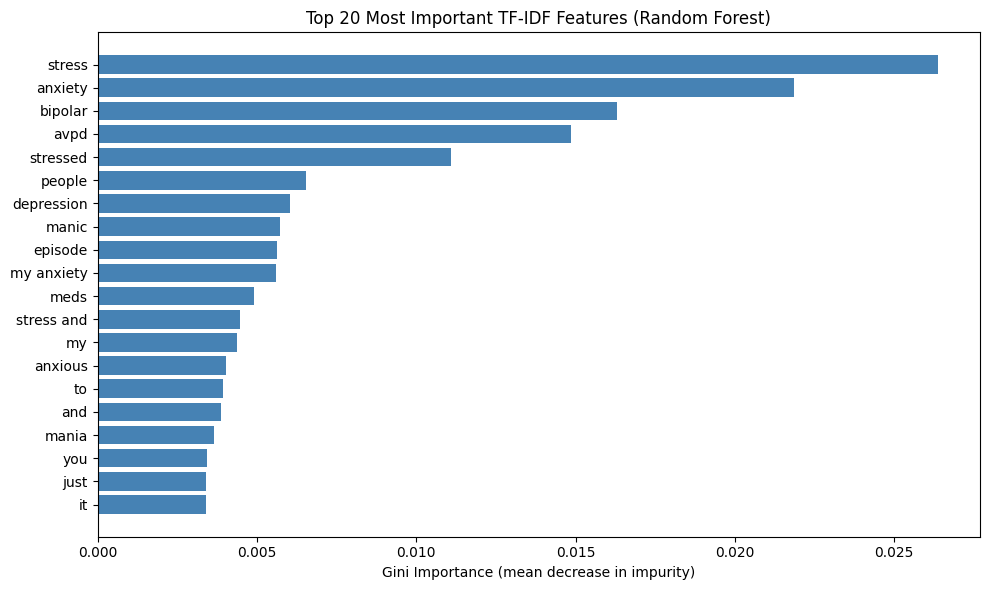

In [8]:
def random_forest(df: pd.DataFrame):
    """
    Train and evaluate a Random Forest on TF-IDF features via 5-fold CV.
    Also extracts and plots the top 20 most important features.

    Parameters
    ----------
    df : pd.DataFrame - cleaned DataFrame with 'clean_text' and 'target'

    Returns
    -------
    rf    : fitted RandomForestClassifier
    tfidf : fitted TfidfVectorizer (needed to interpret feature names)
    """
    print("\n" + "="*60)
    print("Random Forest + Feature Importance (5-fold CV)")
    print("="*60)

    X = df["clean_text"]
    y = df["target"]

    # TF-IDF vectorisation (separate from the classifier this time - RF doesn't use a Pipeline
    # because cross_val_predict would re-fit the vectoriser each fold, which is expensive here)
    tfidf = TfidfVectorizer(
        max_features=10_000,   # Smaller vocab than LR - RF is slower on sparse high-dim data
        ngram_range=(1, 2),    # Same ngram range for comparability
        sublinear_tf=True,
        min_df=2
    )
    X_vec = tfidf.fit_transform(X)   # Shape: (5607, 10000) sparse matrix

    rf = RandomForestClassifier(
        n_estimators=300,          # 300 trees - balance between variance reduction and speed
        class_weight="balanced",   # Same class weighting as LR for fair comparison
        random_state=RANDOM_STATE,
        n_jobs=-1                  # Use all available CPU cores
    )

    # 5-fold stratified CV - same scheme as Section 4
    skf    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    y_pred = cross_val_predict(rf, X_vec, y, cv=skf)

    print(classification_report(y, y_pred, target_names=list(LABEL_MAP.values())))
    macro_f1 = f1_score(y, y_pred, average="macro")
    print(f"Macro F1: {macro_f1:.4f}")

    _plot_confusion(y, y_pred, "Random Forest - Confusion Matrix", "cm_rf.png")

    # --- Feature importance ---
    # Fit on full dataset to get stable importance estimates
    rf.fit(X_vec, y)
    feature_names = tfidf.get_feature_names_out()
    importances   = rf.feature_importances_         # Gini importance per feature
    top_idx       = np.argsort(importances)[-20:][::-1]   # Top 20, descending

    plt.figure(figsize=(10, 6))
    plt.barh(
        [feature_names[i] for i in top_idx],   # Feature labels on y-axis
        importances[top_idx],                   # Importance values on x-axis
        color="steelblue"
    )
    plt.gca().invert_yaxis()   # Highest importance at top
    plt.title("Top 20 Most Important TF-IDF Features (Random Forest)")
    plt.xlabel("Gini Importance (mean decrease in impurity)")
    plt.tight_layout()
    plt.savefig("rf_feature_importance.png", dpi=150)
    plt.show()

    return rf, tfidf


rf_model, rf_tfidf = random_forest(df)


## Section 6: DistilBERT Fine-Tuning 

**Why DistilBERT?**  
DistilBERT refers to a small-sized transformer that has been pretrained on a vast English dataset. As opposed to the TF-IDF representation, it creates contextual embeddings whereby the same token could be encoded differently based on the surrounding context. As an example, the token "down" will have varying embeddings in sentences like "feeling down" versus "lying down.

**Training setup:**
- `distilbert-base-uncased` : 66 million parameters (40% smaller than BERT-base, 97% of performance)
- 80/20 stratified train/test split → 4,485 train / 1,122 test
- AdamW optimiser, lr = 2e-5, linear warmup over 100 steps, gradient clipping (max norm = 1.0)
- 3 epochs, batch size 16, max token length 256

> **Hardware note:** Training on CPU is slow (~2-3 hours). For faster results, run this notebook on **Google Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU).

**Evaluation:** Held-out 20% test set (rather than full CV, transformer CV is prohibitively expensive without a GPU).


DistilBERT Fine-Tuning (manual training loop)
Using device: cpu


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Step 50/281 | Loss: 1.6158
  Epoch 1 | Step 100/281 | Loss: 1.5796
  Epoch 1 | Step 150/281 | Loss: 1.4460
  Epoch 1 | Step 200/281 | Loss: 1.3085
  Epoch 1 | Step 250/281 | Loss: 1.1932
Epoch 1/3 complete — avg loss: 1.1372
  Epoch 2 | Step 50/281 | Loss: 0.6050
  Epoch 2 | Step 100/281 | Loss: 0.5964
  Epoch 2 | Step 150/281 | Loss: 0.5862
  Epoch 2 | Step 200/281 | Loss: 0.5761
  Epoch 2 | Step 250/281 | Loss: 0.5673
Epoch 2/3 complete — avg loss: 0.5635
  Epoch 3 | Step 50/281 | Loss: 0.4285
  Epoch 3 | Step 100/281 | Loss: 0.4308
  Epoch 3 | Step 150/281 | Loss: 0.4068
  Epoch 3 | Step 200/281 | Loss: 0.4130
  Epoch 3 | Step 250/281 | Loss: 0.4086
Epoch 3/3 complete — avg loss: 0.4038
                      precision    recall  f1-score   support

              Stress       0.86      0.90      0.88       220
          Depression       0.74      0.77      0.76       241
             Bipolar       0.91      0.81      0.86       217
Personality Disorder       0.80      0.8

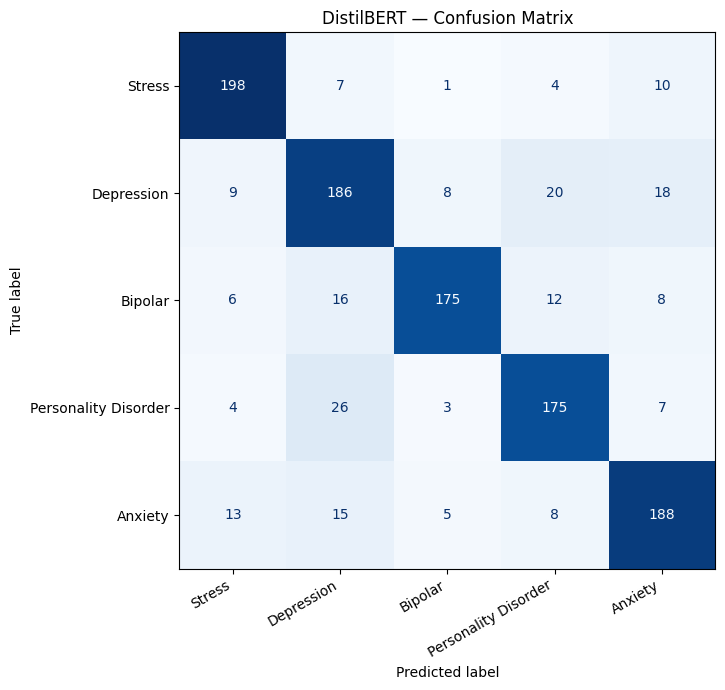

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./distilbert_saved


In [9]:
# =============================================================================
# Custom PyTorch Dataset
# =============================================================================

class RedditDataset(TorchDataset):
    """
    Wraps tokenised post encodings and labels as a PyTorch Dataset
    so they can be served in mini-batches via DataLoader.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings   # Dict of input_ids, attention_mask
        self.labels    = labels      # List of integer class labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Convert each field to a tensor and add the label
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


# =============================================================================
# Fine-tuning function
# =============================================================================

def fine_tune_distilbert(df: pd.DataFrame):
    """
    Fine-tune DistilBERT for 5-class sequence classification.

    Uses an 80/20 stratified split. Trains for BERT_EPOCHS epochs with
    AdamW + linear warmup + gradient clipping, then evaluates on the held-out
    test set and plots the confusion matrix.

    Parameters
    ----------
    df : pd.DataFrame - cleaned DataFrame with 'clean_text' and 'target'

    Returns
    -------
    model     : fine-tuned DistilBertForSequenceClassification
    tokenizer : DistilBertTokenizerFast (needed for inference)
    X_test    : list[str] - held-out post texts
    y_test    : list[int] - held-out true labels
    """
    print("\n" + "="*60)
    print("DistilBERT Fine-Tuning (manual training loop)")
    print("="*60)

    # Use GPU if available - strongly recommended; CPU is ~10× slower
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load pre-trained tokeniser and model head
    tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
    model     = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=NUM_LABELS   # Replace MLM head with a 5-class classifier head
    ).to(device)

    # --- Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        df["clean_text"].tolist(), df["target"].tolist(),
        test_size=0.2,
        stratify=df["target"],
        random_state=RANDOM_STATE
    )

    # --- Tokenise ---
    train_enc = tokenizer(X_train, truncation=True, padding=True, max_length=MAX_LEN)
    test_enc  = tokenizer(X_test,  truncation=True, padding=True, max_length=MAX_LEN)

    train_dataset = RedditDataset(train_enc, y_train)
    test_dataset  = RedditDataset(test_enc,  y_test)

    # shuffle=True for training (breaks order bias); False for evaluation
    train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH)

    # --- Optimiser & scheduler ---
    optimizer   = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(train_loader) * BERT_EPOCHS
    # Linear warmup: ramp LR up for first 100 steps, then decay linearly to 0
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=100, num_training_steps=total_steps
    )

    # ── Training Loop ─────────────────────────────────────────────────────────
    for epoch in range(BERT_EPOCHS):
        model.train()       # Activate dropout (training mode)
        total_loss = 0

        for step, batch in enumerate(train_loader):
            # Move tensors to the active device (GPU or CPU)
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            # Forward pass - loss is computed internally by the HuggingFace model
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            total_loss += loss.item()

            # Backward pass
            loss.backward()
            # Gradient clipping prevents exploding gradients (common in transformer fine-tuning)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()   # Clear gradients before next step

            if (step + 1) % 50 == 0:
                print(f"  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} "
                      f"| Loss: {total_loss/(step+1):.4f}")

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{BERT_EPOCHS} complete - avg loss: {avg_loss:.4f}")

    # ── Evaluation ────────────────────────────────────────────────────────────
    model.eval()   # Disable dropout (evaluation mode)
    all_preds = []

    with torch.no_grad():   # No gradient computation needed during inference
        for batch in test_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            # Take the class with the highest logit as the prediction
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)

    y_pred = np.array(all_preds)
    print(classification_report(y_test, y_pred, target_names=list(LABEL_MAP.values())))
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Macro F1 (DistilBERT): {macro_f1:.4f}")

    _plot_confusion(y_test, y_pred, "DistilBERT - Confusion Matrix", "cm_distilbert.png")

    # Save model and tokeniser so they can be reloaded without retraining
    model.save_pretrained("./distilbert_saved")
    tokenizer.save_pretrained("./distilbert_saved")
    print("Model saved to ./distilbert_saved")

    return model, tokenizer, X_test, y_test


bert_model, bert_tokenizer, X_test, y_test = fine_tune_distilbert(df)


## Section 7: SHAP Explainability

**Why SHAP?**  
SHAP (SHapley Additive exPlanations) assigns contribution to each attribute based on the principles of cooperative game theory. In the case of the Logistic Regression algorithm, the LinearExplainer calculates exact SHAP values effectively on TF-IDF sparse matrices.

**What to look for:**  
Each bar in the above plot corresponds to the average value of the absolute SHAP values per feature using 200 randomly selected posts. The bars denote the average effect of the word on the model’s prediction for the respective category. If a word has a high SHAP value for class k, then it signifies that the word has a significant impact on driving predictions towards class *k*.


**Why Logistic Regression for SHAP?**  
The LinearExplainer computes exact and fast explanations of linear models. Using SHAP on a Random Forest (TreeExplainer) will require transforming the data into a dense matrix of size 10,000 (features) x 5,000 (samples), which can be done, albeit at a cost of considerable computational delays. Evaluating SHAP on DistilBERT will demand DeepExplainer/GradientExplainer and be highly costly without a GPU.


SHAP Explainability (Logistic Regression)


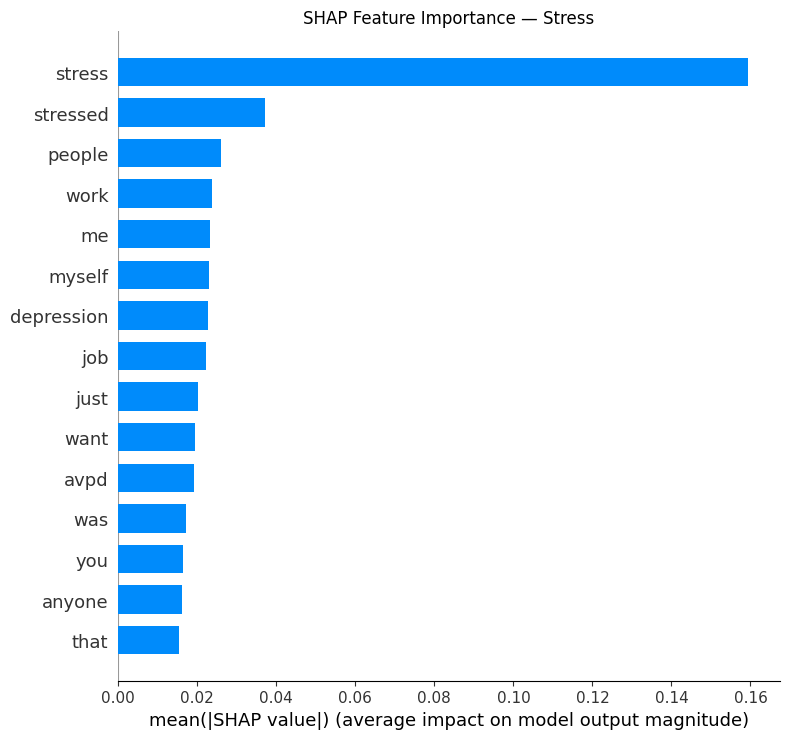

  Saved shap_stress.png


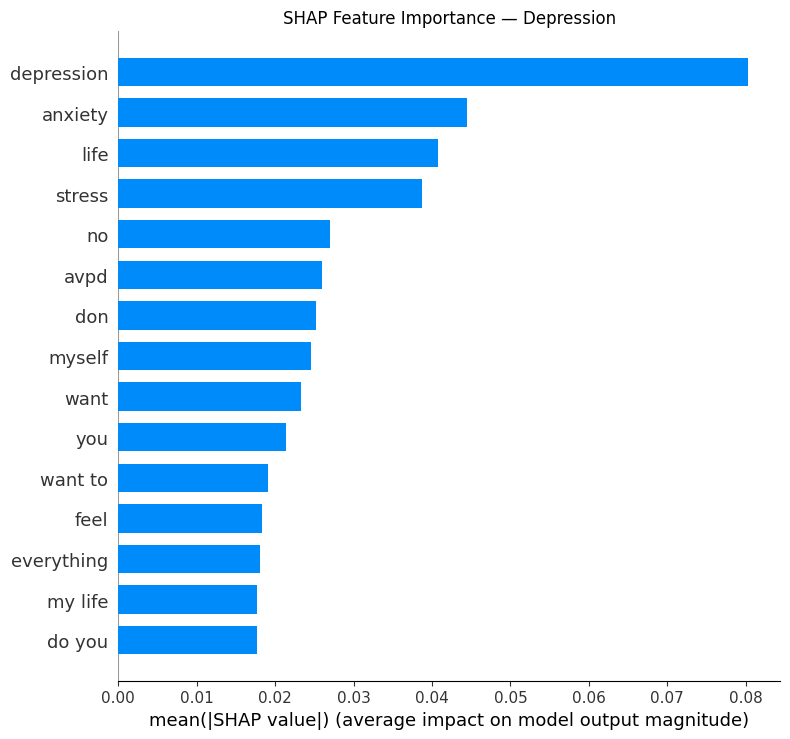

  Saved shap_depression.png


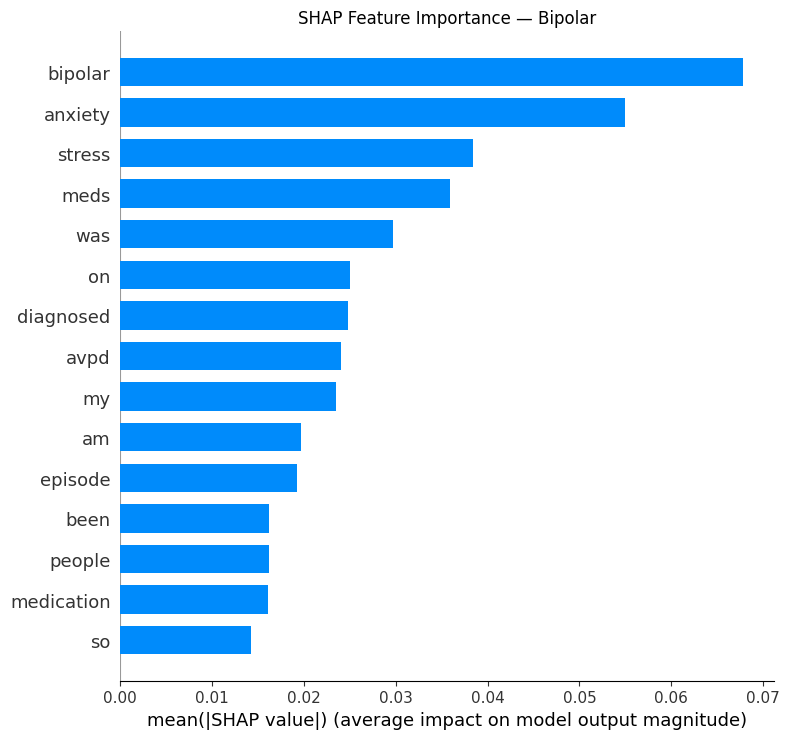

  Saved shap_bipolar.png


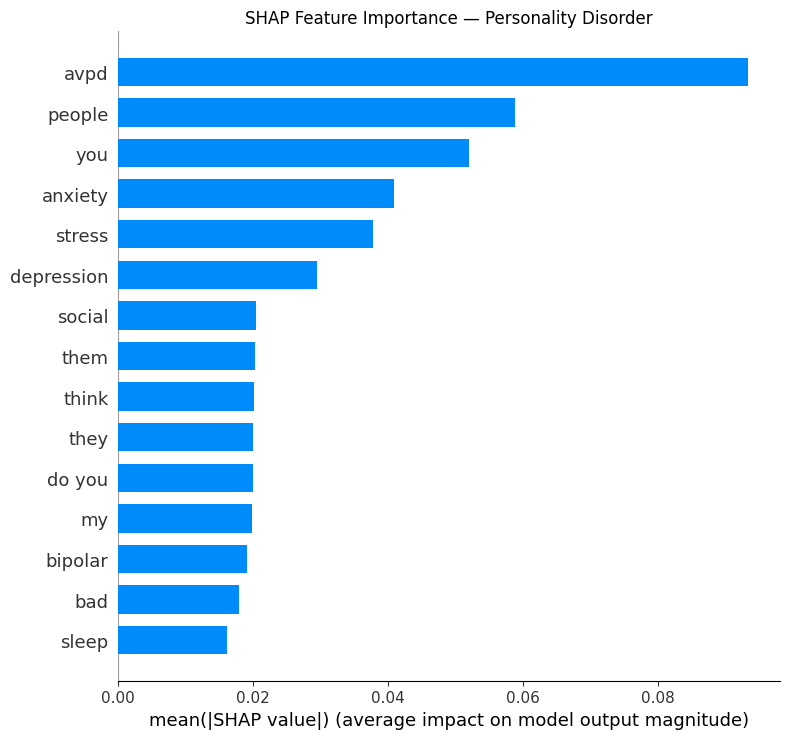

  Saved shap_personality_disorder.png


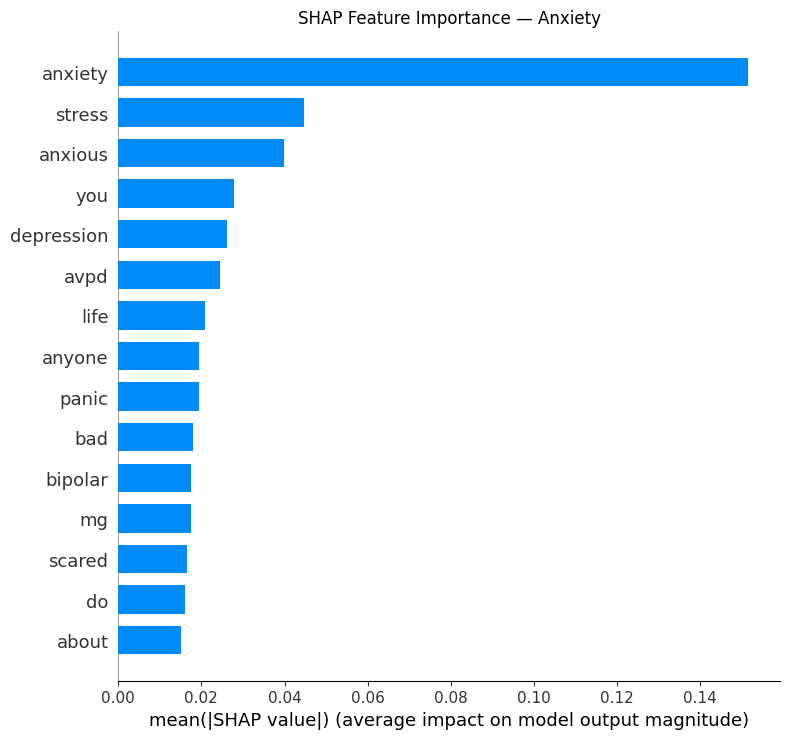

  Saved shap_anxiety.png
SHAP plots saved.


In [10]:
def shap_explain(lr_pipeline, df: pd.DataFrame, n_samples: int = 200):
    """
    Compute and plot SHAP feature importances for the Logistic Regression model.

    Uses LinearExplainer on a random sample of n_samples posts. Produces one
    bar plot per class showing the top 15 most influential TF-IDF features.

    Parameters
    ----------
    lr_pipeline : fitted sklearn Pipeline (TF-IDF + LogisticRegression)
    df          : pd.DataFrame - cleaned DataFrame (for sampling)
    n_samples   : int - number of posts to sample for SHAP (default 200)

    Returns
    -------
    None - saves one PNG per class (shap_stress.png, etc.)
    """
    print("\n" + "="*60)
    print("SHAP Explainability (Logistic Regression)")
    print("="*60)

    # Sample posts for SHAP - larger samples give more stable estimates but take longer
    sample = df["clean_text"].sample(n=n_samples, random_state=RANDOM_STATE)

    # Extract fitted vectoriser and classifier from the pipeline
    tfidf_step    = lr_pipeline.named_steps["tfidf"]
    clf_step      = lr_pipeline.named_steps["clf"]
    X_sample      = tfidf_step.transform(sample)      # Shape: (200, 30000) sparse
    feature_names = list(tfidf_step.get_feature_names_out())   # Vocabulary

    # LinearExplainer computes exact SHAP values for linear models
    explainer   = shap.LinearExplainer(clf_step, X_sample,
                                        feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_sample)   # Shape: (200, 30000, 5)

    # Convert sparse matrix to dense array for SHAP plotting functions
    X_dense = X_sample.toarray() if hasattr(X_sample, "toarray") else np.array(X_sample)

    # Generate one plot per class
    for cls_idx, cls_name in LABEL_MAP.items():
        sv = shap_values[:, :, cls_idx]   # (200, 30000) - SHAP values for class cls_idx

        plt.figure()
        shap.summary_plot(
            sv, X_dense,
            feature_names=feature_names,
            max_display=15,    # Show only the top 15 features
            show=False,
            plot_type="bar"    # Bar chart of mean(|SHAP|) - cleaner than beeswarm for this size
        )
        plt.title(f"SHAP Feature Importance - {cls_name}")
        plt.tight_layout()

        fname = f"shap_{cls_name.lower().replace(' ', '_')}.png"
        plt.savefig(fname, dpi=150)
        plt.show()
        print(f"  Saved {fname}")

    print("SHAP plots saved.")


shap_explain(lr_pipeline, df, n_samples=200)
